In [1]:
library(ggplot2)
library(ggridges)
source("~/helpers.R")
library(reshape2)

In [14]:
#TOGGLE TO TURN SMOOTHING ON/OFF

#NO SMOOTHING
#data=read.table("Tobias_Vierstra_Cor.K562.DNASE.10k.txt",header=TRUE,sep='\t')

#SMOOTHING WITH GAUSSIAN KERNEL OF LENGTH 7
data=read.table("Tobias_Vierstra_Cor.K562.DNASE.10k.Smoothed.Inverted.WithShuffle.txt",header=TRUE,sep='\t')
names(data)=c("BPNetProfile","BPNetCounts","BinaryClass","BinaryReg","GKMExplain","cortype","motifs")
head(data)


,BPNetProfile,BPNetCounts,BinaryClass,BinaryReg,GKMExplain,cortype,motifs
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
1,0.26498632,0.07903942,0.3655372,0.01558128,0.14048857,spearman,tobias
2,0.50789837,-0.04549097,0.4025966,-0.09108662,0.28257346,spearman,tobias
3,-0.07009825,0.41626733,0.1452132,0.30002951,0.25418420,spearman,tobias
4,0.32110714,0.17160653,0.5280483,0.46163541,-0.08173039,spearman,tobias
5,-0.04128678,0.22377518,0.3235737,0.15976936,0.63561328,spearman,tobias
6,0.34771107,-0.01715826,0.1262339,0.03207966,0.09529843,spearman,tobias


In [15]:
data[data$cortype=="spearman_shuff",]

,BPNetProfile,BPNetCounts,BinaryClass,BinaryReg,GKMExplain,cortype,motifs
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
39997,0.037719078,0.028620247,0.0504893149,0.028690182,0.010857831,spearman_shuff,tobias
39998,-0.032509020,-0.003028634,-0.0585552210,-0.012669314,-0.019840447,spearman_shuff,tobias
39999,-0.046795150,-0.038594436,-0.0198363029,-0.023634157,0.035635869,spearman_shuff,tobias
40000,0.011068411,0.024702041,0.0359012759,0.027874832,-0.030501733,spearman_shuff,tobias
40001,-0.019806534,-0.025501441,-0.0207720482,-0.012101695,-0.009190309,spearman_shuff,tobias
40002,0.003695231,0.006115304,-0.0020363565,-0.007070883,-0.024737891,spearman_shuff,tobias
40003,0.022619044,0.037023813,0.0097385869,0.036005592,-0.015963134,spearman_shuff,tobias
40004,0.010348102,0.035663716,0.0281653368,-0.037034639,-0.040776549,spearman_shuff,tobias
40005,-0.001369238,-0.025057156,0.0034830433,0.021330928,-0.028373980,spearman_shuff,tobias


In [16]:
tobias=data[data$motifs=="tobias",]
vierstra=data[data$motifs=="vierstra",]

In [17]:
tobias_spear=tobias[tobias$cortype=="spearman",]
tobias_pears=tobias[tobias$cortype=="pearson",]
tobias_spear_shuff=tobias[tobias$cortype=="spearman_shuff",]
tobias_pears_shuff=tobias[tobias$cortype=="pearson_shuff",]

In [26]:
ks.test(tobias_pears$GKMExplain,tobias_pears_shuff$GKMExplain)


	Two-sample Kolmogorov-Smirnov test

data:  tobias_pears$GKMExplain and tobias_pears_shuff$GKMExplain
D = 0.78574, p-value < 2.2e-16
alternative hypothesis: two-sided


In [6]:
tobias_spear=rbind(tobias_spear,tobias_spear_shuff)
tobias_pears=rbind(tobias_pears,tobias_pears_shuff)

In [7]:
head(tobias_spear)

,BPNetProfile,BPNetCounts,BinaryClass,BinaryReg,GKMExplain,cortype,motifs
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
1,0.26498632,0.07903942,0.3655372,0.01558128,0.14048857,spearman,tobias
2,0.50789837,-0.04549097,0.4025966,-0.09108662,0.28257346,spearman,tobias
3,-0.07009825,0.41626733,0.1452132,0.30002951,0.25418420,spearman,tobias
4,0.32110714,0.17160653,0.5280483,0.46163541,-0.08173039,spearman,tobias
5,-0.04128678,0.22377518,0.3235737,0.15976936,0.63561328,spearman,tobias
6,0.34771107,-0.01715826,0.1262339,0.03207966,0.09529843,spearman,tobias


In [8]:
tobias_spear=melt(tobias_spear,index='cortype')
tobias_pears=melt(tobias_pears,index='cortype')


Using cortype, motifs as id variables

Using cortype, motifs as id variables



In [9]:
tobias_spear$cortype=factor(tobias_spear$cortype)

In [10]:
options(repr.plot.width=10, repr.plot.height=8)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Picking joint bandwidth of 0.0175

Warning message:
“Removed 250 rows containing non-finite values (stat_density_ridges).”


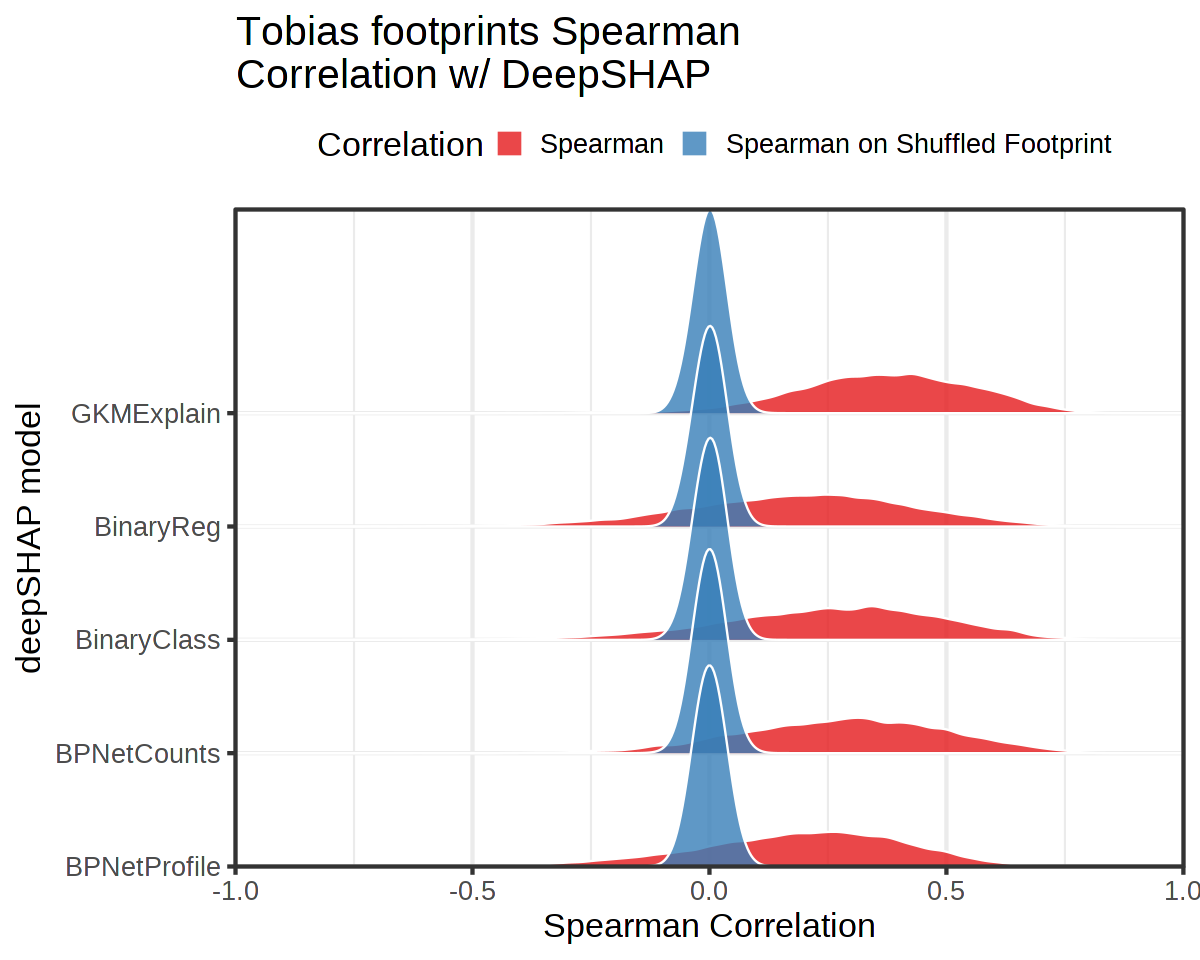

In [11]:
library(dplyr)
tobias_spear %>%  
ggplot(aes(y = variable)) +
  geom_density_ridges(
    aes(x = value, fill = cortype), 
    alpha = .8, color = "white", from = -1, to = 1
  ) +
  labs(
    x = "Spearman Correlation",
    y = "deepSHAP model",
    title = "Tobias footprints Spearman \nCorrelation w/ DeepSHAP"
  ) +
  scale_y_discrete(expand = c(0, 0)) +
  scale_x_continuous(expand = c(0, 0)) +
  coord_cartesian(clip = "off") +
  scale_fill_manual(name="Correlation",values = c("#E41A1C50", "#377EB850"), labels = c("Spearman", "Spearman on Shuffled Footprint")) +
  theme_ridges(grid = FALSE)+
  theme_bw(20)+
  theme(legend.position = "top")

Picking joint bandwidth of 0.0197

Warning message:
“Removed 250 rows containing non-finite values (stat_density_ridges).”


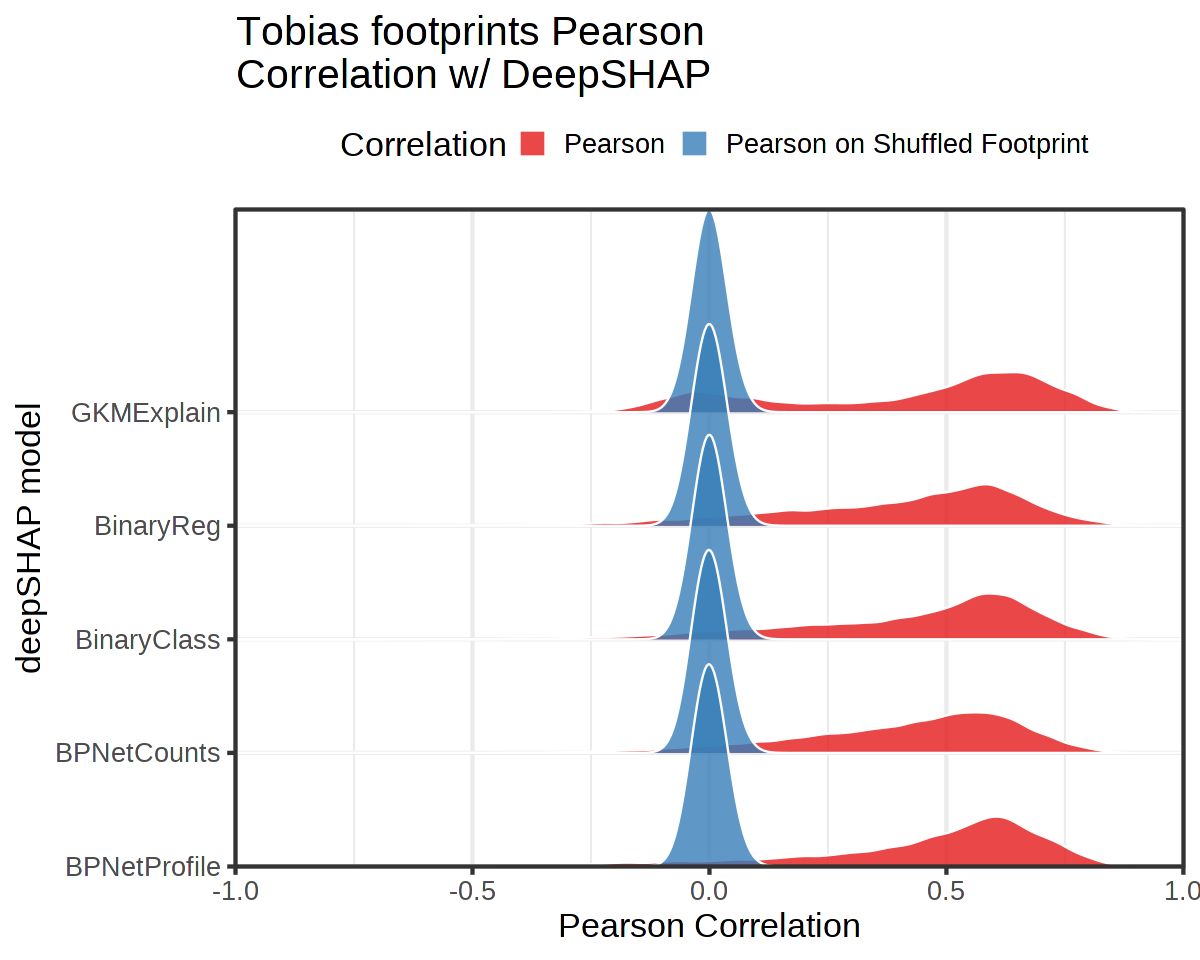

In [12]:
library(dplyr)
tobias_pears %>%  
ggplot(aes(y = variable)) +
  geom_density_ridges(
    aes(x = value, fill = cortype), 
    alpha = .8, color = "white", from = -1, to = 1
  ) +
  labs(
    x = "Pearson Correlation",
    y = "deepSHAP model",
    title = "Tobias footprints Pearson \nCorrelation w/ DeepSHAP"
  ) +
  scale_y_discrete(expand = c(0, 0)) +
  scale_x_continuous(expand = c(0, 0)) +
  coord_cartesian(clip = "off") +
  scale_fill_manual(name="Correlation",values = c("#E41A1C50", "#377EB850"), labels = c("Pearson", "Pearson on Shuffled Footprint")) +
  theme_ridges(grid = FALSE)+
  theme_bw(20)+
  theme(legend.position = "top")

Picking joint bandwidth of 0.0175

Warning message:
“Removed 250 rows containing non-finite values (stat_density_ridges).”


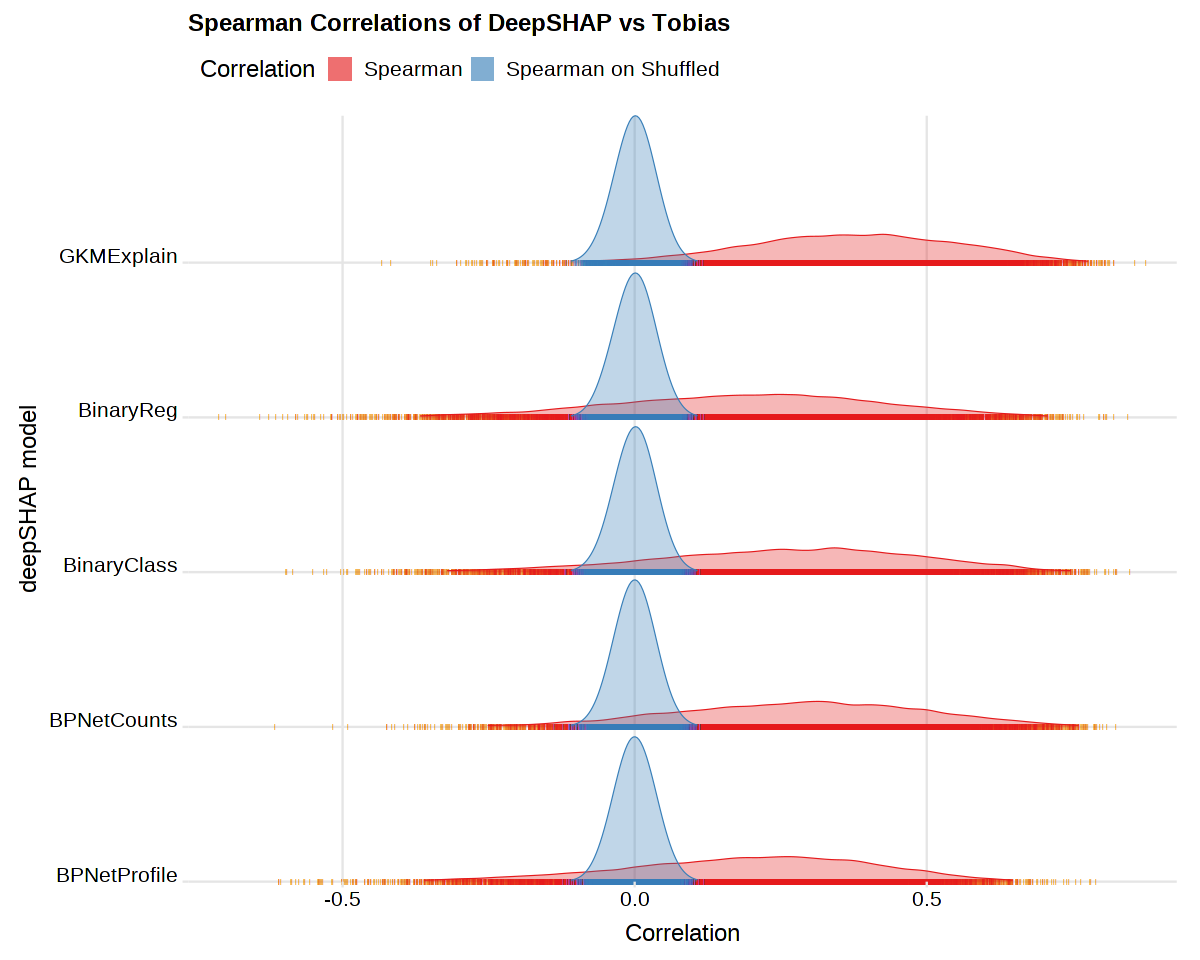

In [13]:
p=ggplot(tobias_spear,
       aes(y=variable,
           x=value,
           color=cortype,
           point_color=cortype,
           fill=cortype))+
  geom_density_ridges(
    jittered_points=TRUE,
    scale=0.95,
    rel_min_height=0.01,
    point_shape = "|", point_size = 1, size = 0.25,
    position = position_points_jitter(height = 0)
  ) +
  scale_y_discrete(expand = c(0, 0), name="deepSHAP model") +
  scale_x_continuous(expand = c(0, 0), name = "Correlation") +
  scale_fill_manual(name="Correlation",values = c("#E41A1C50", "#377EB850"), labels = c("Spearman", "Spearman on Shuffled")) +
  scale_color_manual(values = c('#e41a1c','#377eb8'), guide = "none") +
  scale_discrete_manual("point_color", values = c('#e41a1c','#377eb8'), guide = "none") +
  coord_cartesian(clip = "off") +
  guides(fill = guide_legend(
    override.aes = list(
      fill = c("#E41A1CA0","#377EB8A0"),
      color = NA, point_color = NA)
  )
  ) +
  ggtitle("Spearman Correlations of DeepSHAP vs Tobias") +
  theme_ridges(center = TRUE)+
  theme(legend.position = "top") 
p

Picking joint bandwidth of 0.031

Warning message:
“Removed 760 rows containing non-finite values (stat_density_ridges).”


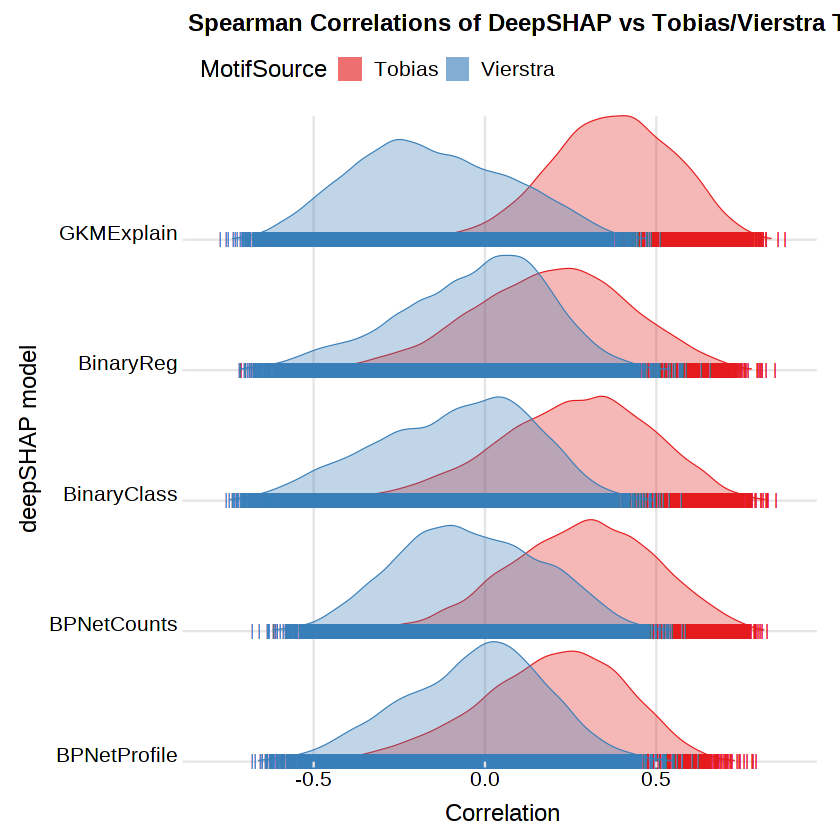

In [59]:

p=ggplot(data_spear,
       aes(y=variable,
           x=value,
           color=motifs,
           point_color=motifs,
           fill=motifs))+
  geom_density_ridges(
    jittered_points=TRUE,
    scale=0.95,
    rel_min_height=0.01,
    point_shape = "|", point_size = 3, size = 0.25,
    position = position_points_jitter(height = 0)
  ) +
  scale_y_discrete(expand = c(0, 0), name="deepSHAP model") +
  scale_x_continuous(expand = c(0, 0), name = "Correlation") +
  scale_fill_manual(name="MotifSource",values = c("#E41A1C50", "#377EB850"), labels = c("Tobias", "Vierstra")) +
  scale_color_manual(values = c('#e41a1c','#377eb8'), guide = "none") +
  scale_discrete_manual("point_color", values = c('#e41a1c','#377eb8'), guide = "none") +
  coord_cartesian(clip = "off") +
  guides(fill = guide_legend(
    override.aes = list(
      fill = c("#E41A1CA0","#377EB8A0"),
      color = NA, point_color = NA)
  )
  ) +
  ggtitle("Spearman Correlations of DeepSHAP vs Tobias/Vierstra Tracks") +
  theme_ridges(center = TRUE)+
  theme(legend.position = "top") 
p

Picking joint bandwidth of 0.0301

Warning message:
“Removed 760 rows containing non-finite values (stat_density_ridges).”


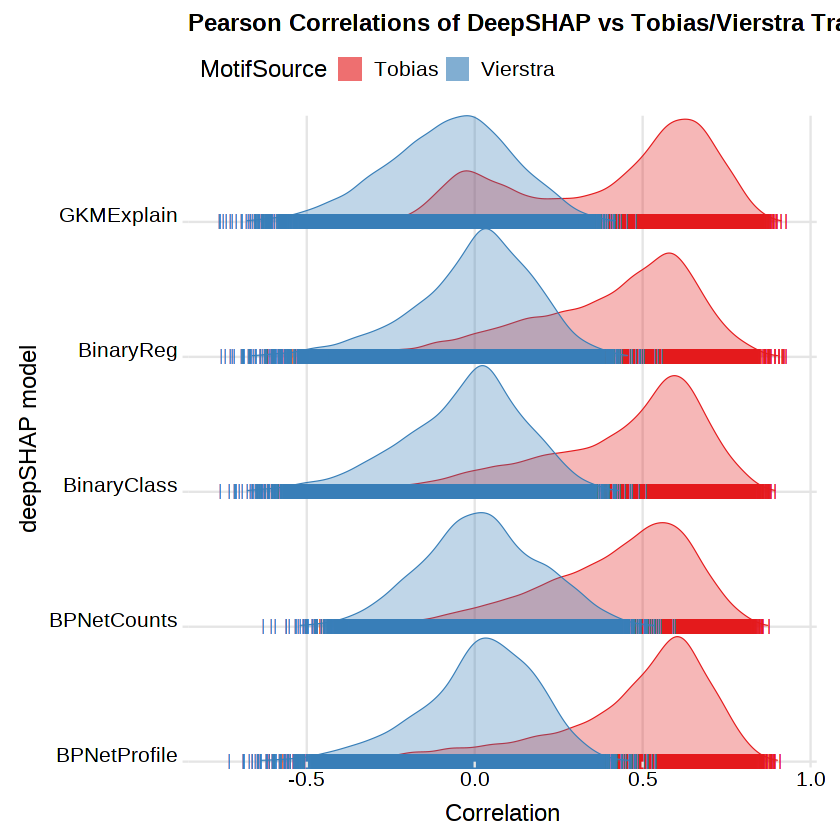

In [60]:

p=ggplot(data_pears,
       aes(y=variable,
           x=value,
           color=motifs,
           point_color=motifs,
           fill=motifs))+
  geom_density_ridges(
    jittered_points=TRUE,
    scale=0.95,
    rel_min_height=0.01,
    point_shape = "|", point_size = 3, size = 0.25,
    position = position_points_jitter(height = 0)
  ) +
  scale_y_discrete(expand = c(0, 0), name="deepSHAP model") +
  scale_x_continuous(expand = c(0, 0), name = "Correlation") +
  scale_fill_manual(name="MotifSource",values = c("#E41A1C50", "#377EB850"), labels = c("Tobias", "Vierstra")) +
  scale_color_manual(values = c('#e41a1c','#377eb8'), guide = "none") +
  scale_discrete_manual("point_color", values = c('#e41a1c','#377eb8'), guide = "none") +
  coord_cartesian(clip = "off") +
  guides(fill = guide_legend(
    override.aes = list(
      fill = c("#E41A1CA0","#377EB8A0"),
      color = NA, point_color = NA)
  )
  ) +
  ggtitle("Pearson Correlations of DeepSHAP vs Tobias/Vierstra Tracks") +
  theme_ridges(center = TRUE)+
  theme(legend.position = "top") 
p

In [14]:
head(data_pears)

,cortype,motifs,variable,value
,<fct>,<fct>,<fct>,<dbl>
1,pearson,tobias,BPNetProfile,0.6416338
2,pearson,tobias,BPNetProfile,0.5932045
3,pearson,tobias,BPNetProfile,0.5501727
4,pearson,tobias,BPNetProfile,0.4554776
5,pearson,tobias,BPNetProfile,0.3846032
6,pearson,tobias,BPNetProfile,0.2697487
